In [1]:
# https://coastwatch.glerl.noaa.gov/statistics/great-lakes-ice-concentration/

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from grabmustang import geoStation

from noisemodels import accNLNM,accNHNM

In [2]:
# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 

In [3]:
figdir = './figs/'

In [4]:
# Load NDBC spectral wave density
# https://www.ndbc.noaa.gov/

path2data = "./ndbc_spectral_wave_density/"

df1 = pd.read_csv(path2data+"45006w2013.txt", delim_whitespace=True)
df2 = pd.read_csv(path2data+"45006w2014.txt", delim_whitespace=True)

frames = [df1, df2]

df = pd.concat(frames)

# Convert to datetime
df['date'] = pd.to_datetime(dict(year=df.YY, month=df.MM, day=df.DD, hour=df.hh))

df = df.set_index('date')
df = df.drop(columns=['YY','MM','DD','hh','mm'])

# Convert to dB (10*log10)
df.iloc[:,:] = 10*np.log10(df.iloc[:,:] + 1e-4)

# Resample data every 24 hours by taking mean
df = df.resample('D').mean()
# df = df.resample('D').median()

# Save index as date column
df['date'] = df.index

# Index date between start and end date
start_date = '2013-03-27'
end_date = '2013-09-23'
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

df

,.0200,.0325,.0375,.0425,.0475,.0525,.0575,.0625,.0675,.0725,...,.3400,.3500,.3650,.3850,.4050,.4250,.4450,.4650,.4850,date
date,,,,,,,,,,,,,,,,,,,,,
2013-03-27,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-40.000000,-40.000000,...,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,2013-03-27
2013-03-28,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-40.000000,-40.000000,...,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,-40.000000,2013-03-28
2013-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-03-29
2013-03-30,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-40.000000,-40.000000,...,-28.516904,-28.452120,-28.705980,-26.687778,-27.155817,-25.358304,-27.585328,-31.091905,-35.545953,2013-03-30
2013-03-31,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-39.040335,-39.040335,-37.955691,...,-10.957474,-11.837463,-12.902374,-14.432413,-15.061726,-16.933155,-19.590887,-22.528524,-24.843059,2013-03-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-09-19,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-40.000000,-40.000000,...,-30.864365,-31.046080,-28.269677,-27.320088,-27.347975,-27.333698,-30.284170,-36.514224,-36.514224,2013-09-19
2013-09-20,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-39.164866,-40.000000,...,-14.094084,-14.936162,-15.180659,-17.269624,-17.260022,-20.249135,-25.085386,-26.264264,-31.524130,2013-09-20
2013-09-21,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.0,-40.000000,-39.040335,-39.040335,...,-12.329281,-12.699677,-13.941686,-15.114993,-14.958427,-17.796535,-19.788936,-22.213126,-27.348460,2013-09-21


In [ ]:
from datetime import datetime, timedelta
from time import sleep

# Get seismic spectra

# Ely, Minnesota, USA
US_EYMN = geoStation('US', 'EYMN', ['**'], ['BHZ'], label='Ely, Minnesota, USA')
station_list = [US_EYMN]

dof = 0
plotunit = 2 # 2=acceleration, 1=velocity, 0=displacement
# plotunit = 0 # 2=acceleration, 1=velocity, 0=displacement

# Vector of datetimes spaced every 24 hours
# datevec = np.arange(df['date'].dt.round('1d').min(),df['date'].dt.round('1d').max(), timedelta(days=1))
datevec = df['date'].to_numpy()
datevec_end = np.append(df['date'][1:].to_numpy(),(df['date'][-1]+(df['date'][-1]-df['date'][-2])).to_numpy())

# Get average noise properties
PSD_avg = 0
PSDs = []
icnt = 0
pd.options.mode.chained_assignment = None  # default='warn' suppress annoying warning
for station in station_list:
    for iday in range(len(datevec)):
        tstart = datevec[iday] #- timedelta(1) # -24 hours
        # tend = datevec[iday] + timedelta(1) # +24 hours
        tend = datevec_end[iday]

        tstart_str = tstart.astype('datetime64[s]').item().strftime('%Y-%m-%d')
        tend_str = tend.astype('datetime64[s]').item().strftime('%Y-%m-%d')

        print('Working on '+tstart_str+' to '+tend_str)

        try:
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        except:
            print('IRIS unhappy... trying again')
            sleep(2)
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        
        if len(station.text_percentiles[dof]) < 50:
            print('skipping '+tstart_str)

            PSDs.append(np.nan*np.ones(freqs.shape))

            continue

        freqs = station.freqs[dof]
        
        PSD = 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit))

        PSDs.append(PSD)
        
        PSD_avg = PSD_avg + PSD
        icnt+=1

PSD_avg = PSD_avg / icnt
PSDs = np.asarray(PSDs)


Working on 2013-03-27 to 2013-03-28
Working on 2013-03-28 to 2013-03-29
Working on 2013-03-29 to 2013-03-30
Working on 2013-03-30 to 2013-03-31
Working on 2013-03-31 to 2013-04-01
Working on 2013-04-01 to 2013-04-02
Working on 2013-04-02 to 2013-04-03
Working on 2013-04-03 to 2013-04-04
Working on 2013-04-04 to 2013-04-05
Working on 2013-04-05 to 2013-04-06
Working on 2013-04-06 to 2013-04-07
Working on 2013-04-07 to 2013-04-08
Working on 2013-04-08 to 2013-04-09
Working on 2013-04-09 to 2013-04-10
Working on 2013-04-10 to 2013-04-11
Working on 2013-04-11 to 2013-04-12
Working on 2013-04-12 to 2013-04-13
Working on 2013-04-13 to 2013-04-14
Working on 2013-04-14 to 2013-04-15
Working on 2013-04-15 to 2013-04-16
Working on 2013-04-16 to 2013-04-17
Working on 2013-04-17 to 2013-04-18
Working on 2013-04-18 to 2013-04-19
Working on 2013-04-19 to 2013-04-20
Working on 2013-04-20 to 2013-04-21
Working on 2013-04-21 to 2013-04-22
Working on 2013-04-22 to 2013-04-23
Working on 2013-04-23 to 201

In [6]:
# Calculate power within frequency band

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 1 #2 #1/0.65
# fmin = 0.2*2
# fmax = 0.4*2

PSD_band = PSDs[:,(freqs>=fmin) & (freqs<=fmax)].mean(axis=1)
# PSD_band = np.median(PSDs[:,(freqs>=fmin) & (freqs<=fmax)],axis=1)
PSD_band_std = PSDs[:,(freqs>=fmin) & (freqs<=fmax)].std(axis=1)
PSD_band_stderr = PSDs[:,(freqs>=fmin) & (freqs<=fmax)].std(axis=1)/np.sqrt(PSDs[:,(freqs>=fmin) & (freqs<=fmax)].shape[1])

(0.0052556, 10)

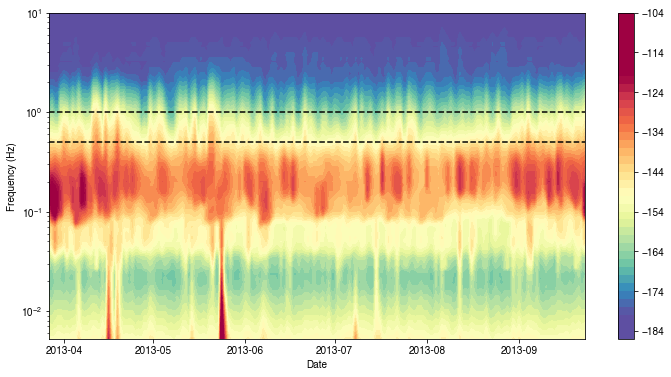

In [7]:
# Plot spectrogram of seismic noise

fs,ts = np.meshgrid(freqs,datevec)

fig = plt.figure(figsize=(12,6))
ax = plt.axes()
c = ax.contourf(ts,fs,PSDs,50, vmin=-180, vmax=-120, cmap='Spectral_r')
ax.plot([df['date'].min(), df['date'].max()],[fmin, fmin],'--',color='k')
ax.plot([df['date'].min(), df['date'].max()],[fmax, fmax],'--',color='k')
cb = plt.colorbar(c)
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')
ax.set_ylim(fs.min(),10)

Text(0, 0.5, '0.5-1 Hz Seismic Noise (dB)')

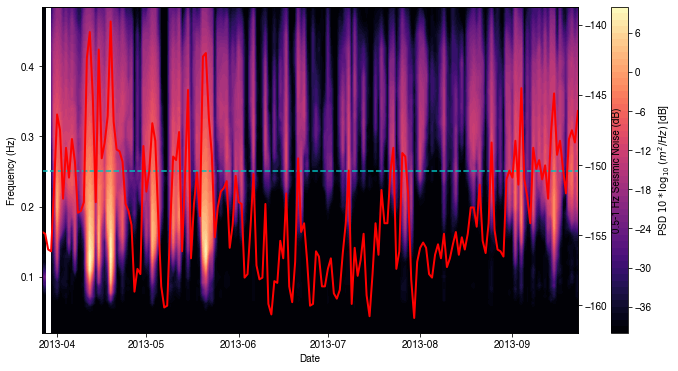

In [8]:
import scipy

# Define fmin and fmax
fmin_wave = fmin/2
fmax_wave = fmax/2

column_names = list(df.columns.values)
# column_names
freqs_wave = np.array(column_names[:-1],dtype='float')
date_wave = df.iloc[:,-1].to_numpy()
power_wave = df.iloc[:,:-1].to_numpy()

fs,ts = np.meshgrid(freqs_wave,date_wave)

fig = plt.figure(figsize=(12,6))
ax = plt.axes()
c = ax.contourf(ts,fs,power_wave,50, cmap='magma')
cb = plt.colorbar(c)
cb.set_label('PSD $10*\log_{10}(m^2/Hz)$ [dB]')
ax.plot([ts.min(), ts.max()],[fmin_wave, fmin_wave],'--',color='c')
# ax.plot([ts.min(), ts.max()],[fmax_wave, fmax_wave],'--',color='c')
ax.set_xlabel('Date')
ax.set_ylabel('Frequency (Hz)')

ax2 = ax.twinx()
ax2.plot(datevec, PSD_band, '-',
              c='r', lw=2)
ax2.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='k')


/tmp/ipykernel_15964/43038385.py:4: RuntimeWarning: Mean of empty slice
  power_wave_av = np.nanmean(power_wave,axis=1)


Text(0, 0.5, 'PSD $10*\\log_{10}(m^2/Hz)$ [dB]')

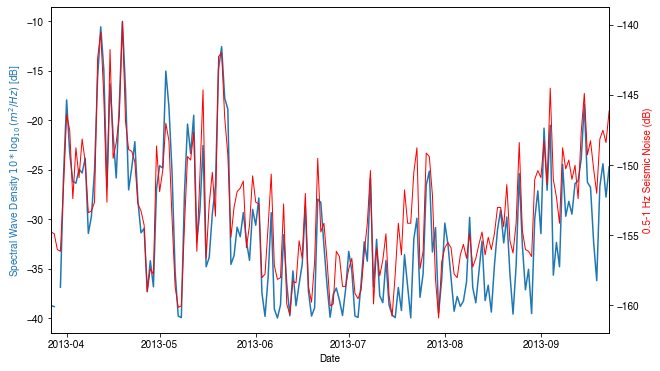

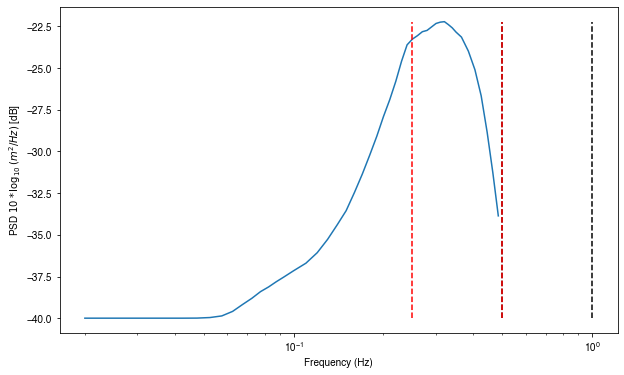

In [9]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

power_wave_av = np.nanmean(power_wave,axis=1)

fig = plt.figure(figsize=(10,6))
ax = plt.axes()
ax.plot(date_wave,power_wave_av)
# ax.plot(date_wave,np.nanmean(power_wave[:,(freqs_wave>=fmin_wave) & (freqs_wave<=fmax_wave)],axis=1))
# ax.plot(date_wave,np.nanmean(power_wave[:,(freqs_wave>=0.1) & (freqs_wave<=0.25)],axis=1))
# ax.plot(date_wave[:-49],moving_average((10*np.log10(power_wave)).mean(axis=1),50))
# ax.plot(date_wave,10*np.log10(power_wave[:,freqs_wave==0.14]))
ax.set_ylabel('Spectral Wave Density $10*\log_{10}(m^2/Hz)$ [dB]',color='tab:blue')
ax.set_xlabel('Date')

ax2 = ax.twinx()
ax2.plot(datevec, PSD_band, '-',
              c='r', lw=1)
ax2.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='r')
ax.set_xlim(datevec[0],datevec[-1])

fig = plt.figure(figsize=(10,6))
ax = plt.axes()
ax.plot(freqs_wave,np.nanmean(power_wave,axis=0))
ax.plot([fmin,fmin],[np.nanmean(power_wave,axis=0).min(),np.nanmean(power_wave,axis=0).max()],'--',color='k')
ax.plot([fmax,fmax],[np.nanmean(power_wave,axis=0).min(),np.nanmean(power_wave,axis=0).max()],'--',color='k')
ax.plot([fmin/2,fmin/2],[np.nanmean(power_wave,axis=0).min(),np.nanmean(power_wave,axis=0).max()],'--',color='r')
ax.plot([fmax/2,fmax/2],[np.nanmean(power_wave,axis=0).min(),np.nanmean(power_wave,axis=0).max()],'--',color='r')
ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_ylabel('PSD $10*\log_{10}(m^2/Hz)$ [dB]')


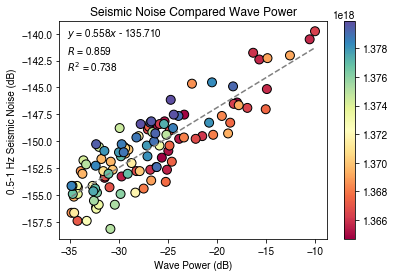

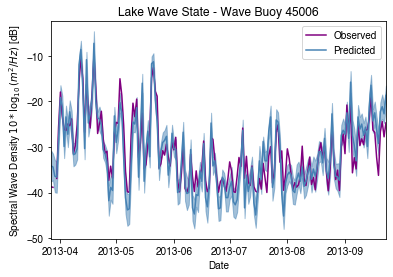

In [10]:
# Plot Correlation scatter

# Calculate R^2 for seismic noise and ice cover
# power_wave_av_c = power_wave_av[:-1]
power_wave_av_good = power_wave_av[power_wave_av>=-35]
# power_wave_av_good = np.nanmean(power_wave[:,(freqs_wave>=fmin_wave) & (freqs_wave<=fmax_wave)],axis=1)
# power_wave_av_good = power_wave_av_good[power_wave_av>=-35]
# date_wave_c = date_wave[:-1]
date_wave_good = date_wave[power_wave_av>=-35]
PSD_band_good = PSD_band[power_wave_av>=-35]
datevec_good = datevec[power_wave_av>=-35]
# slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(PSD_band_good,power_wave_av_good)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(power_wave_av_good,PSD_band_good)

R2 = r_value**2

hh, ax = plt.subplots()

sc = ax.scatter(power_wave_av_good,PSD_band_good, marker='o', s=80,
              c=date_wave_good, cmap='Spectral', edgecolor='black')
# ax.set_ylim([-190, -100])
cb = plt.colorbar(sc)

ax.plot([power_wave_av_good.min(),power_wave_av_good.max()], [power_wave_av_good.min()*slope+intercept,power_wave_av_good.max()*slope+intercept], '--',color='gray')

ax.annotate("$y$ = {:.3f}$x$ - {:.3f}".format(slope,np.abs(intercept)), (0.03, 0.93), xycoords='axes fraction')
ax.annotate("$R$ = {:.3f}".format(r_value), (0.03, 0.85), xycoords='axes fraction')
ax.annotate("$R^2$ = {:.3f}".format(R2), (0.03, 0.77), xycoords='axes fraction')

ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Wave Power (dB)')
ax.set_title('Seismic Noise Compared Wave Power')
# ax.legend()




hh, ax = plt.subplots()
power_wave_av_pre = (PSD_band-intercept)/slope
power_wave_av_pre_min = (PSD_band-PSD_band_stderr-intercept)/slope
power_wave_av_pre_max = (PSD_band+PSD_band_stderr-intercept)/slope
# Plot wave spectral density predictions
ax.fill_between(date_wave,
    power_wave_av_pre_min,
    power_wave_av_pre_max, 
    color='steelblue', alpha=0.5)
ax.plot(date_wave,power_wave_av,'-',c='purple',label='Observed')
ax.plot(datevec,power_wave_av_pre,'-',c='steelblue',label='Predicted')
ax.set_ylabel('Spectral Wave Density $10*\log_{10}(m^2/Hz)$ [dB]')
ax.set_xlim(datevec[0],datevec[-1])
ax.set_title('Lake Wave State - Wave Buoy 45006')
ax.set_xlabel('Date')
ax.legend()

/tmp/ipykernel_15964/2393181682.py:9: RuntimeWarning: Mean of empty slice
  power_wave_av = np.nanmean(power_wave,axis=1)
/tmp/ipykernel_15964/2393181682.py:11: RuntimeWarning: Mean of empty slice
  power_wave_av_DF = np.nanmean(power_wave[:,mask_freq],axis=1)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


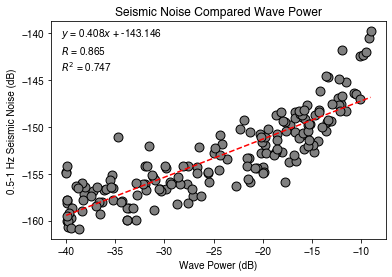

In [11]:
# Plot Correlation scatter for secondary microseism wave power

# Define fmin and fmax
# fmin_wave = fmin/4
# fmax_wave = fmax/4
fmin_wave = fmin/2
fmax_wave = fmax/2

power_wave_av = np.nanmean(power_wave,axis=1)
mask_freq = (freqs_wave>=fmin_wave) & (freqs_wave<=fmax_wave)
power_wave_av_DF = np.nanmean(power_wave[:,mask_freq],axis=1)

# Calculate R^2 for seismic noise and ice cover
# power_wave_av_c = power_wave_av[:-1]
# power_wave_av_good = power_wave_av[power_wave_av>=-35]
power_wave_av_DF_good = power_wave_av_DF[power_wave_av_DF>=-55]
# power_wave_av_good = np.nanmean(power_wave[:,(freqs_wave>=fmin_wave) & (freqs_wave<=fmax_wave)],axis=1)
# power_wave_av_good = power_wave_av_good[power_wave_av>=-35]
# date_wave_c = date_wave[:-1]
date_wave_DF_good = date_wave[power_wave_av_DF>=-55]
PSD_band_DF_good = PSD_band[power_wave_av_DF>=-55]
datevec_DF_good = datevec[power_wave_av_DF>=-55]
# slope_DF, intercept_DF, r_value_DF, p_value_DF, std_err_DF = scipy.stats.linregress(PSD_band_DF_good,power_wave_av_DF_good)
slope_DF, intercept_DF, r_value_DF, p_value_DF, std_err_DF = scipy.stats.linregress(power_wave_av_DF_good,PSD_band_DF_good)

R2_DF = r_value_DF**2

hh, ax = plt.subplots()

# sc = ax.scatter(PSD_band_DF_good, power_wave_av_DF_good, marker='o', s=80,
#               c=date_wave_DF_good, cmap='Spectral', edgecolor='black')
# sc = ax.scatter(PSD_band_DF_good, power_wave_av_DF_good, marker='o', s=80,
#               c='gray', edgecolor='black')
sc = ax.scatter(power_wave_av_DF_good,PSD_band_DF_good, marker='o', s=80,
              c='gray', edgecolor='black')
# ax.set_ylim([-190, -100])
# cb = plt.colorbar(sc)

# ax.plot([PSD_band_DF_good.min(),PSD_band_DF_good.max()], [PSD_band_DF_good.min()*slope_DF+intercept_DF,PSD_band_DF_good.max()*slope_DF+intercept_DF], '--',color='red')
ax.plot([power_wave_av_DF_good.min(),power_wave_av_DF_good.max()], [power_wave_av_DF_good.min()*slope_DF+intercept_DF,power_wave_av_DF_good.max()*slope_DF+intercept_DF], '--',color='red')

ax.annotate("$y$ = {:.3f}$x$ + {:.3f}".format(slope_DF,intercept_DF), (0.03, 0.93), xycoords='axes fraction')
ax.annotate("$R$ = {:.3f}".format(r_value_DF), (0.03, 0.85), xycoords='axes fraction')
ax.annotate("$R^2$ = {:.3f}".format(R2_DF), (0.03, 0.77), xycoords='axes fraction')

ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Wave Power (dB)')
ax.set_title('Seismic Noise Compared Wave Power')
# ax.legend()

plt.savefig(figdir+'wavespectra_noise_correlation_'+station.station+'_'+str(fmin_wave)+'_'+str(fmax_wave)+'Hz.pdf', bbox_inches='tight')

/tmp/ipykernel_15964/1762266378.py:39: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in c.collections:
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


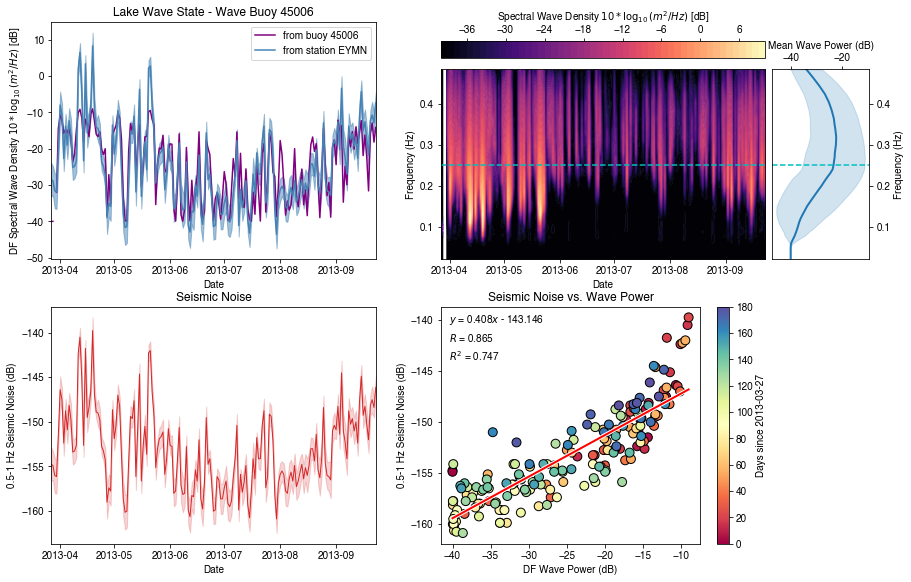

In [12]:
# Use power only in predicted secondary microseism band

# power_wave_av_DF_pre = PSD_band*slope_DF+intercept_DF
power_wave_av_DF_pre = (PSD_band-intercept_DF)/slope_DF
power_wave_av_DF_pre_min = (PSD_band-PSD_band_stderr-intercept_DF)/slope_DF
power_wave_av_DF_pre_max = (PSD_band+PSD_band_stderr-intercept_DF)/slope_DF
# power_wave_av_pre = PSD_band*slope+intercept

# fig = plt.figure(figsize=(7,4))
# ax = plt.axes()

fig, ax = plt.subplots(2, 2, figsize=(6.4*2, 4.8*2), sharex=False, gridspec_kw={"width_ratios": [1, 1]})

# Plot wave spectral density predictions
ax[0,0].fill_between(date_wave,
    power_wave_av_DF_pre_min,
    power_wave_av_DF_pre_max, 
    color='steelblue', alpha=0.5)
ax[0,0].plot(date_wave,power_wave_av_DF,'-',c='purple',label='from buoy 45006')
# ax[0,0].plot(date_wave,power_wave_av,'-',c='red',label='Observed')
ax[0,0].plot(datevec,power_wave_av_DF_pre,'-',c='steelblue',label='from station '+station.station)
# ax[0,0].plot(date_wave,power_wave_av,'-',c='purple',label='Observed')
# ax[0,0].plot(datevec,power_wave_av_pre,'-',c='steelblue',label='Predicted')
# ax[0,0].legend()
# ax.plot(date_wave,np.nanmean(power_wave[:,(freqs_wave>=fmin_wave) & (freqs_wave<=fmax_wave)],axis=1))
# ax.plot(date_wave,np.nanmean(power_wave[:,(freqs_wave>=0.1) & (freqs_wave<=0.25)],axis=1))
# ax.plot(date_wave[:-49],moving_average((10*np.log10(power_wave)).mean(axis=1),50))
# ax.plot(date_wave,10*np.log10(power_wave[:,freqs_wave==0.14]))
# ax.set_ylabel('Spectral Wave Density $10*\log_{10}(m^2/Hz)$ [dB]',color='tab:blue')
ax[0,0].set_ylabel('DF Spectral Wave Density $10*\log_{10}(m^2/Hz)$ [dB]')
ax[0,0].set_xlim(datevec[0],datevec[-1])
ax[0,0].set_title('Lake Wave State - Wave Buoy 45006')
ax[0,0].set_xlabel('Date')
ax[0,0].legend()

# Plot wave spectral density spectrogram
c = ax[0,1].contourf(ts,fs,power_wave,50, cmap='magma')
# Add thin contour lines with matching colors
for collection in c.collections:
    collection.set_edgecolor(collection.get_facecolor())
    collection.set_linewidth(0.5)  # Adjust linewidth as needed
cb = plt.colorbar(c,orientation='horizontal',location = 'top')
cb.set_label('Spectral Wave Density $10*\log_{10}(m^2/Hz)$ [dB]')
ax[0,1].plot([ts.min(), ts.max()],[fmin_wave, fmin_wave],'--',color='c')
ax[0,1].plot([ts.min(), ts.max()],[fmax_wave, fmax_wave],'--',color='c')
ax[0,1].set_xlabel('Date')
ax[0,1].set_ylabel('Frequency (Hz)')
ax[0,1].set_xlim(datevec[0],datevec[-1])
ax[0,1].set_ylim(fs.min(),fs.max())
# Create an inset axes for the histogram on the right side
# The arguments for inset_axes are [x, y, width, height] in figure coordinates
# Here, we place it on the right edge, with 0.2 width and 1 height relative to the main axes.
# The `bbox_to_anchor` and `loc` arguments help position it relative to the main axes' extent.
ax_hist = ax[0,1].inset_axes([1.02, 0, 0.3, 1], transform=ax[0,1].transAxes)
# Plot the histogram in the inset axes
ax_hist.fill_betweenx(freqs_wave,
    np.nanmean(power_wave[:,:],axis=0)-np.nanstd(power_wave[:,:],axis=0),
    np.nanmean(power_wave[:,:],axis=0)+np.nanstd(power_wave[:,:],axis=0), 
    color='tab:blue', alpha=0.2)
ax_hist.plot(np.nanmean(power_wave[:,:],axis=0),freqs_wave,linewidth=2,color='tab:blue')
ax_hist.axhline(y=fmin_wave, color='c', linestyle='--') 
ax_hist.axhline(y=fmax_wave, color='c', linestyle='--') 
# ax_hist.set_ylabel('Frequency (Hz)') # Label for the vertical axis of the histogram
# ax_hist.set_xticks([]) # Remove x-axis ticks for a cleaner look
# ax_hist.set_yticks([]) # Remove y-axis ticks for a cleaner look
ax_hist.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,right=True, labelright=True, left=False, labelleft=False)
ax_hist.set_ylim(freqs_wave.min(),freqs_wave.max())
ax_hist.set_ylabel('Frequency (Hz)')
ax_hist.yaxis.set_label_position("right")
ax_hist.set_xlabel('Mean Wave Power (dB)')
ax_hist.xaxis.set_label_position("top")


# Plot seismic noise
PSD_band_stderr
ax[1,0].fill_between(datevec,
    PSD_band-PSD_band_stderr,
    PSD_band+PSD_band_stderr, 
    color='tab:red', alpha=0.2)
ax[1,0].plot(datevec, PSD_band, '-', c='tab:red', lw=1)
ax[1,0].set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')
ax[1,0].set_xlabel('Date')
ax[1,0].set_xlim(datevec[0],datevec[-1])
ax[1,0].set_title('Seismic Noise')
# # use formatters to specify major and minor ticks
# ax[1,0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# ax[1,0].xaxis.set_minor_formatter(mdates.DateFormatter("%Y-%m-%d"))
# # Rotates and right-aligns the x labels so they don't crowd each other.
# for label in ax[1,0].get_xticklabels(which='major'):
#     label.set(rotation=30, horizontalalignment='right')

# Plot correlation scatter of seismic noise and wave power
sc = ax[1,1].scatter(power_wave_av_DF_good, PSD_band_DF_good, marker='o', s=80,
              c=(pd.to_datetime(date_wave_DF_good) - pd.to_datetime(date_wave_DF_good[0])).days, cmap='Spectral', edgecolor='black')
# ax[1,1].set_ylim([-190, -100])
cb = plt.colorbar(sc)
cb.set_label(r'Days since '+pd.Timestamp(date_wave_DF_good[0]).strftime('%Y-%m-%d'))
ax[1,1].plot([power_wave_av_DF_good.min(),power_wave_av_DF_good.max()], [power_wave_av_DF_good.min()*slope_DF+intercept_DF,power_wave_av_DF_good.max()*slope_DF+intercept_DF], '-',color='w',linewidth=4)
ax[1,1].plot([power_wave_av_DF_good.min(),power_wave_av_DF_good.max()], [power_wave_av_DF_good.min()*slope_DF+intercept_DF,power_wave_av_DF_good.max()*slope_DF+intercept_DF], '-',color='r',linewidth=2)
ax[1,1].annotate("$y$ = {:.3f}$x$ - {:.3f}".format(slope_DF,np.abs(intercept_DF)), (0.03, 0.93), xycoords='axes fraction')
ax[1,1].annotate("$R$ = {:.3f}".format(r_value_DF), (0.03, 0.85), xycoords='axes fraction')
ax[1,1].annotate("$R^2$ = {:.3f}".format(R2_DF), (0.03, 0.77), xycoords='axes fraction')
ax[1,1].set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')
# ax[1,1].set_xlim([5e-3, 16])
ax[1,1].set_xlabel('DF Wave Power (dB)')
ax[1,1].set_title('Seismic Noise vs. Wave Power')
# ax[1,1].legend()

plt.savefig(figdir+'a3a_wavespectra_noise_compare_'+station.station+'_'+str(fmin_wave)+'_'+str(fmax_wave)+'Hz_v3.pdf', bbox_inches='tight')

In [13]:
date_wave[0]

numpy.datetime64('2013-03-27T00:00:00.000000000')